<a href="https://colab.research.google.com/github/russellyaoduphd-cyber/520.637-HW-2/blob/main/AgentReasoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Agent reasoning：递归记忆、信息诊断与干预

**问题：**同样的交互历史经过不同记忆更新策略后，决定下一动作所需的信息是否仍然可用？

这是一个可复现的 **诊断实验原型**，不训练模型，也不是 MEM1 的复现或 AIS 充分性的证明。
不预设推理更新一定更好；两种策略都成功、都失败或没有差别，都是有效结果。

**先运行：**默认 `BACKEND="demo"`，点击 **Runtime → Run all**。这只检查实验管线，
规则程序不代表 LLM，所有表和导出文件会标明 `demo`。然后将配置改为 `BACKEND="hf"`，
在 Colab 选择 GPU 并重新从头运行，才会得到真实的开源模型结果。无需付费 API 或 API key。
首次会下载模型；默认 1.5B 仍是小模型，可把 `MODEL_ID` 改为更强的兼容模型。

Notebook 包含：配对任务、两种更新策略、完整历史基线、状态/历史检查器、
自然错误的最小修复（若存在）、单独标记的人工错误阳性对照、轨迹与计算量导出。


## 1. 符号与实验边界

沿用讨论中的含义：环境状态 $x_t$；观测 $o_t$；完整历史 $h_t$；
内部状态 $z_t\in\mathbb R^d$；决策 reasoning $r_t$；动作 $a_t$。
任务 $q$ 在所有 episode 中相同：两个开关相同选 RED，不同选 BLUE。奖励不用 $r_t$ 表示。

环境逐条发出线索。读取阶段的动作是 WAIT，$r_t$ 为空；
更新器 $F(z_t,r_t,a_t,o_{t+1})$ 将已有记忆和新观测压成新的 $z_{t+1}$。
全部线索结束后，决策器只读取最终 $z_t$，生成简短 $r_t$ 和最终动作 $a_t$。
**更新器内部生成的摘要是 $F$ 的计算，不与约定中的决策 $r_t$ 混用。**

本原型的 $z_t$ 是固定长度的 token-ID 数组，空位用 -1 填充；不是已学好的连续 latent，
也不把 token-ID 的欧氏距离解释为语义距离。固定任务规则属于所有策略共享的输入。
真实模型采用 greedy decoding，使更新规则在固定模型/运行设置下可重复。

两组只有更新指令不同：`facts` 保存开关事实，`reasoning` 尝试压缩成相同/不同的结论。
这检验 **提示词诱导的更新策略**，不能声称 facts 组的神经网络内部“没有推理”。
最终决策器、检查器模型、记忆上限和各阶段生成上限在两组间相同。


In [ ]:
# Configuration: edit this cell, then Run all.
BACKEND = "demo"                  # "demo" (plumbing only) or "hf" (real local LLM)
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
MODEL_REVISION = "main"            # Export records the resolved model commit when available.
SEED = 637
REPEATS_PER_SWITCH_PAIR = 1        # Each repeat contains all four (A, B) pairs.
DELAY_PAIRS = ((0, 0), (3, 3))     # (distractors between clues, distractors after both)
MEMORY_BUDGETS = (32,)             # Shared token cap; d is constant within each comparison.
UPDATE_MAX_NEW_TOKENS = 64
ACTOR_MAX_NEW_TOKENS = 32
CHECKER_MAX_NEW_TOKENS = 96        # Same stronger readout budget for z and z+h.
RUN_INTERVENTIONS = True
MAX_NATURAL_REPAIRS = 4            # Eligibility is defined before inspecting results.
BOOTSTRAP_SAMPLES = 2000
RUN_NAME = "switch_memory_v1"

assert BACKEND in {"demo", "hf"}
assert REPEATS_PER_SWITCH_PAIR >= 1
assert MEMORY_BUDGETS and all(isinstance(n, int) and n > 0 for n in MEMORY_BUDGETS)
assert DELAY_PAIRS and all(g >= 0 and t >= 0 for g, t in DELAY_PAIRS)


In [ ]:
# Only the real-LLM path installs model dependencies. No model download in demo mode.
import importlib.util
import subprocess
import sys

base_packages = [p for p in ("numpy", "pandas", "matplotlib")
                 if importlib.util.find_spec(p) is None]
if base_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *base_packages])
if BACKEND == "hf":
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "transformers==4.57.1", "accelerate>=1.0,<2", "torch>=2.2"])

import copy
import hashlib
import itertools
import json
import math
import platform
import random
import re
import time
import zipfile
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if hasattr(value, "to_string") else value)

random.seed(SEED)
np.random.seed(SEED)
TASK = ("Two switches A and B each have a fixed value, 0 or 1. "
        "If A and B have the SAME value, RED is safe. If they DIFFER, BLUE is safe. "
        "A stored relation=EQUAL is sufficient evidence for RED; relation=DIFFERENT "
        "is sufficient evidence for BLUE, even if the individual values were discarded. "
        "The switch values never change during an episode. "
        "Only observations explicitly reporting switch A or B are evidence. "
        "Room labels, display numbers and other scenery are irrelevant. "
        "At the final decision choose the safe door. A correct choice earns 1, otherwise 0.")
CONDITIONS = ("facts", "reasoning")


## 2. 可控环境与独立真值

每种延迟下均衡生成 `(A,B) = (0,0),(0,1),(1,0),(1,1)`，随机化线索顺序和干扰内容。
两种更新策略共享同一 episode。**真值只交给 evaluator，不传给更新器或决策器。**
完整历史是实际观测、WAIT 动作和空的读取阶段 reasoning，不包含隐藏真值。


In [ ]:
@dataclass(frozen=True)
class Episode:
    episode_id: str
    switch_a: int
    switch_b: int
    gap: int
    tail: int
    observations: tuple

    @property
    def correct_door(self):
        return "RED" if self.switch_a == self.switch_b else "BLUE"

    @property
    def correct_relation(self):
        return "EQUAL" if self.switch_a == self.switch_b else "DIFFERENT"

    def public_history(self):
        # This is the information actually seen by the agent, not hidden state.
        return [{"o_t": o, "r_t": "", "a_t": "WAIT"} for o in self.observations]


def make_episodes(seed, repeats, delay_pairs):
    rng = random.Random(seed)
    episodes = []
    serial = 0
    for gap, tail in delay_pairs:
        for repeat in range(repeats):
            pairs = list(itertools.product((0, 1), repeat=2))
            rng.shuffle(pairs)
            for a, b in pairs:
                clues = [f"Switch A = {a}.", f"Switch B = {b}."]
                rng.shuffle(clues)
                def distraction():
                    return (f"Scenery only: room label {rng.randrange(100, 1000)}; "
                            f"display digit {rng.randrange(2)}; wall {rng.choice(['plain', 'striped'])}.")
                observations = ([clues[0]] + [distraction() for _ in range(gap)]
                                + [clues[1]] + [distraction() for _ in range(tail)])
                episodes.append(Episode(f"ep-{serial:04d}", a, b, gap, tail, tuple(observations)))
                serial += 1
    return episodes


EPISODES = make_episodes(SEED, REPEATS_PER_SWITCH_PAIR, DELAY_PAIRS)
display(pd.DataFrame([{"episode": e.episode_id, "A (evaluator only)": e.switch_a,
                      "B (evaluator only)": e.switch_b, "gap": e.gap, "tail": e.tail,
                      "correct (evaluator only)": e.correct_door} for e in EPISODES]))


## 3. 两组提示词与模型后端

更新时只能读取旧 $z_t$ 和新观测，不偷偷回看 $h_t$。
facts 保留 `A=...; B=...`；reasoning 在证据齐全后可保留 `relation=EQUAL/DIFFERENT`。
这样的格式便于独立检查，但也偏向这个简单任务；不能泛化成所有 reasoning 的比较。

所有模型输出完整保留到日志。解析失败记为 `INVALID`，未知答案记为 `UNKNOWN`；
都计入失败，绝不从真值补答案。超过记忆容量时按同一规则截断，并统计截断率。


In [ ]:
UPDATE_COMMON = (
    "You maintain a bounded memory for a decision task. "
    "Read ONLY the supplied previous memory and new observation. "
    "Never invent an unseen switch value. Preserve relevant information on scenery-only turns. "
    "Return only the updated memory, with no preamble, markdown or explanation. "
)
UPDATE_INSTRUCTION = {
    "facts": ("Keep observed switch facts. Use A=0 or A=1, and B=0 or B=1, only when known. "
              "Use ? for an unknown value. Do not compute the relation or choose a door. "
              "Preferred format: A=?; B=?"),
    "reasoning": ("Reason about what will determine the safe door. When both switch values "
                  "are known, replace the facts by relation=EQUAL or relation=DIFFERENT. "
                  "If a previous relation is already known, retain it because switches never change. "
                  "Before both are known retain the available A=0/A=1 or B=0/B=1 fact. "
                  "Do not guess a relation before both values are known.")
}


def build_messages(kind, payload):
    if kind == "update":
        system = UPDATE_COMMON + UPDATE_INSTRUCTION[payload["condition"]]
        user = (TASK + f"\nMemory cap: {payload['budget']} tokenizer tokens.\n"
                + "Previous memory:\n" + (payload["memory"] or "(empty)")
                + "\nNew observation:\n" + payload["observation"])
    elif kind == "decide":
        system = ("Solve the supplied task using only the available evidence. "
                  "You may briefly check the facts. Do not invent missing information. "
                  "End with exactly one line FINAL=RED or FINAL=BLUE or FINAL=UNKNOWN. "
                  "A known relation is sufficient; do not demand the individual switch values. "
                  "Use FINAL=UNKNOWN only if neither both switch values nor a relation is known, "
                  "or if the available claims conflict.")
        user = TASK + "\nAvailable memory:\n" + (payload.get("memory", "") or "(none)")
        if "history" in payload:
            user += ("\nFull observed history (raw observations are authoritative if memory conflicts):\n"
                     + json.dumps(payload["history"], ensure_ascii=False))
    else:
        raise ValueError(kind)
    return [{"role": "system", "content": system}, {"role": "user", "content": user}]


def symbolic_decode(text):
    """Conservative decoder for the declared tiny schema, not a general semantic oracle."""
    claims = {k: {int(v) for v in re.findall(rf"\b{k}\s*=\s*([01])\b", text)}
              for k in ("A", "B")}
    relations = set(re.findall(r"\brelation\s*=\s*(EQUAL|DIFFERENT)\b", text, re.I))
    relations = {r.upper() for r in relations}
    recognized = bool(claims["A"] or claims["B"] or relations)
    if any(len(v) > 1 for v in claims.values()) or len(relations) > 1:
        return {"door": "UNKNOWN", "status": "conflicting_claims", "recognized": recognized}
    candidates = []
    for a, b in itertools.product((0, 1), repeat=2):
        if claims["A"] and a not in claims["A"]:
            continue
        if claims["B"] and b not in claims["B"]:
            continue
        relation = "EQUAL" if a == b else "DIFFERENT"
        if relations and relation not in relations:
            continue
        candidates.append("RED" if a == b else "BLUE")
    doors = set(candidates)
    status = "decodable" if len(doors) == 1 else ("conflicting_claims" if not doors else "inconclusive")
    return {"door": next(iter(doors)) if len(doors) == 1 else "UNKNOWN",
            "status": status, "recognized": recognized}


def parse_final(text):
    answers = re.findall(r"^\s*FINAL\s*=\s*(RED|BLUE|UNKNOWN)\s*[.!]?\s*$", text, re.M | re.I)
    return answers[0].upper() if len(answers) == 1 else "INVALID"


class DemoTokenizer:
    # One Unicode character per token. Do not compare demo token counts with HF counts.
    def encode(self, text, add_special_tokens=False):
        return [ord(c) for c in text]

    def decode(self, ids, **kwargs):
        return "".join(chr(int(i)) for i in ids)


class DemoBackend:
    name = "demo_symbolic_not_llm"
    tokenizer = DemoTokenizer()
    revision = "not-applicable"

    def generate(self, kind, payload, max_new_tokens):
        messages = build_messages(kind, payload)
        if kind == "update":
            text = payload["memory"] + "\n" + payload["observation"]
            values = {k: re.findall(rf"\b{k}\s*=\s*([01])\b", text) for k in ("A", "B")}
            facts = "; ".join(f"{k}={v[-1]}" for k, v in values.items() if v)
            prior = re.findall(r"\brelation=(EQUAL|DIFFERENT)\b", payload["memory"])
            if payload["condition"] == "reasoning" and values["A"] and values["B"]:
                out = "relation=" + ("EQUAL" if values["A"][-1] == values["B"][-1] else "DIFFERENT")
            elif payload["condition"] == "reasoning" and prior:
                out = "relation=" + prior[-1]
            else:
                out = facts or "A=?; B=?"
        else:
            evidence = payload.get("memory", "")
            if "history" in payload:
                evidence = "\n".join(step["o_t"] for step in payload["history"])
            out = "FINAL=" + symbolic_decode(evidence)["door"]
        out = out[:max_new_tokens]
        return {"text": out, "input_tokens": sum(len(m["content"]) for m in messages),
                "output_tokens": len(out), "seconds": 0.0, "hit_generation_cap": len(out) == max_new_tokens}


class HFBackend:
    def __init__(self, model_id, revision):
        import torch
        import transformers
        from transformers import AutoModelForCausalLM, AutoTokenizer
        self.torch = torch
        self.name = model_id
        self.versions = {"torch": torch.__version__, "transformers": transformers.__version__}
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        if self.device == "cpu":
            print("CPU inference selected; use a Colab GPU for a larger run.")
        torch.manual_seed(SEED)
        if self.device == "cuda":
            torch.cuda.manual_seed_all(SEED)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id, revision=revision, trust_remote_code=False)
        dtype = torch.float16 if self.device == "cuda" else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id, revision=revision, dtype=dtype, trust_remote_code=False).to(self.device).eval()
        self.revision = getattr(self.model.config, "_commit_hash", None) or revision

    def generate(self, kind, payload, max_new_tokens):
        messages = build_messages(kind, payload)
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to(self.device)
        n_input = inputs["input_ids"].shape[-1]
        limit = getattr(self.model.config, "max_position_embeddings", 32768)
        if n_input + max_new_tokens > limit:
            raise ValueError("Prompt exceeds model context; no silent truncation of history is allowed.")
        if self.device == "cuda":
            self.torch.cuda.synchronize()
        start = time.perf_counter()
        with self.torch.inference_mode():
            output = self.model.generate(**inputs, do_sample=False, max_new_tokens=max_new_tokens,
                                         pad_token_id=self.tokenizer.eos_token_id,
                                         use_cache=True)
        if self.device == "cuda":
            self.torch.cuda.synchronize()
        elapsed = time.perf_counter() - start
        ids = output[0, n_input:]
        return {"text": self.tokenizer.decode(ids, skip_special_tokens=True),
                "input_tokens": int(n_input), "output_tokens": int(ids.numel()),
                "seconds": elapsed, "hit_generation_cap": int(ids.numel()) == max_new_tokens}


backend = DemoBackend() if BACKEND == "demo" else HFBackend(MODEL_ID, MODEL_REVISION)
print("BACKEND:", backend.name)
if BACKEND == "demo":
    print("DEMO ONLY: tables below are software checks, not LLM findings.")


## 4. 固定维度状态与递归更新

只有这一段负责持久化记忆。完整历史保存在独立 evaluator 日志中；不传入 $F$。
更新原文、截断后的记忆、token 数和调用输入都会记录，便于核对遗忘发生在哪一轮。


In [ ]:
class MemoryCodec:
    def __init__(self, tokenizer, budget):
        if budget < 1:
            raise ValueError("Memory budget must be positive")
        self.tokenizer, self.budget = tokenizer, int(budget)

    def encode(self, text):
        ids = self.tokenizer.encode(text, add_special_tokens=False)
        z = np.full(self.budget, -1, dtype=np.int64)
        kept = ids[:self.budget]
        z[:len(kept)] = kept
        return z, len(ids) > self.budget

    def decode(self, z):
        if np.shape(z) != (self.budget,):
            raise ValueError("State has the wrong fixed dimension")
        return self.tokenizer.decode([int(i) for i in z if i >= 0], skip_special_tokens=True)

    def used(self, z):
        return int(np.sum(z >= 0))


CALL_LOG = []


def call_model(kind, payload, cap, context):
    # Only public payload is sent to the backend; context contains log IDs, not truth.
    result = backend.generate(kind, payload, cap)
    entry = {"call_id": len(CALL_LOG), "backend": backend.name, "kind": kind,
             "cap": cap, **context, "payload": copy.deepcopy(payload), **result}
    CALL_LOG.append(entry)
    return entry


def F(z_t, r_t, a_t, o_next, *, codec, condition, context):
    """Reading-phase state transition; the previous public action is WAIT."""
    if a_t != "WAIT" or r_t != "":
        raise ValueError("This toy environment updates memory only during WAIT steps.")
    payload = {"condition": condition, "budget": codec.budget,
               "memory": codec.decode(z_t), "observation": o_next}
    result = call_model("update", payload, UPDATE_MAX_NEW_TOKENS, context)
    z_next, truncated = codec.encode(result["text"])
    return z_next, {"update_call_id": result["call_id"], "raw_update": result["text"],
                    "memory": codec.decode(z_next), "memory_tokens": codec.used(z_next),
                    "memory_truncated": truncated}


def decide(memory, *, cap, context, history=None):
    payload = {"memory": memory}
    if history is not None:
        payload["history"] = history
    result = call_model("decide", payload, cap, context)
    return {"action": parse_final(result["text"]), "r_t": result["text"],
            "call_id": result["call_id"]}


## 5. 配对实验

每个 episode 先跑完整历史 actor 基线，然后对两种更新策略分别运行：

1. `actor_z`：最终 actor 只读压缩状态。
2. `checker_z`：同一模型、较大的生成上限，只读状态。
3. `checker_zh`：同一个 checker、相同上限，读状态 + 完整历史。
4. `schema_decodable`：独立的精确小型 schema decoder 是否能从显式事实/关系确定正确门。

`checker_z` 失败而 `checker_zh` 成功，是历史中可能仍有有用信息的证据；不是遗忘的证明。
schema decoder 不理解自由文本，它的失败也可能只是格式不匹配。二者均不等同于 Markov 性。


In [ ]:
RESULTS, TRAJECTORIES, BASELINES = [], [], []
for ep_index, episode in enumerate(EPISODES):
    history = episode.public_history()
    base = decide("", cap=ACTOR_MAX_NEW_TOKENS,
                  context={"episode_id": episode.episode_id, "stage": "full_history_actor"},
                  history=history)
    BASELINES.append({"episode_id": episode.episode_id, "gap": episode.gap, "tail": episode.tail,
                      "action": base["action"], "correct": base["action"] == episode.correct_door})
    for budget in MEMORY_BUDGETS:
        codec = MemoryCodec(backend.tokenizer, budget)
        # Alternate order to reduce systematic runtime/order effects.
        order = CONDITIONS if ep_index % 2 == 0 else tuple(reversed(CONDITIONS))
        for condition in order:
            context = {"episode_id": episode.episode_id, "condition": condition, "budget": budget}
            z, _ = codec.encode("")
            trajectory = []
            for t, observation in enumerate(episode.observations):
                prior = codec.decode(z)
                z, info = F(z, "", "WAIT", observation, codec=codec, condition=condition,
                            context={**context, "stage": "update", "step": t + 1})
                trajectory.append({**context, "step": t + 1, "observation": observation,
                                   "prior_memory": prior, "z_t": z.tolist(), **info})
            TRAJECTORIES.extend(trajectory)
            memory = codec.decode(z)
            actor = decide(memory, cap=ACTOR_MAX_NEW_TOKENS, context={**context, "stage": "actor_z"})
            check_z = decide(memory, cap=CHECKER_MAX_NEW_TOKENS, context={**context, "stage": "checker_z"})
            check_zh = decide(memory, cap=CHECKER_MAX_NEW_TOKENS,
                              context={**context, "stage": "checker_zh"}, history=history)
            symbolic = symbolic_decode(memory)
            RESULTS.append({**context, "backend": backend.name, "gap": episode.gap, "tail": episode.tail,
                            "truth": episode.correct_door, "final_memory": memory, "z_t": z.tolist(),
                            "memory_tokens": codec.used(z),
                            "truncated_updates": sum(x["memory_truncated"] for x in trajectory),
                            "num_updates": len(trajectory),
                            "full_history_actor_correct": base["action"] == episode.correct_door,
                            "actor_z": actor["action"], "actor_r_t": actor["r_t"],
                            "checker_z": check_z["action"], "checker_zh": check_zh["action"],
                            "actor_correct": actor["action"] == episode.correct_door,
                            "checker_z_correct": check_z["action"] == episode.correct_door,
                            "checker_zh_correct": check_zh["action"] == episode.correct_door,
                            "schema_status": symbolic["status"],
                            "schema_decodable": symbolic["door"] == episode.correct_door,
                            "schema_recognized": symbolic["recognized"]})
    print(f"Completed {ep_index + 1}/{len(EPISODES)} episodes ({backend.name})")

results = pd.DataFrame(RESULTS)
trajectories = pd.DataFrame(TRAJECTORIES)
baselines = pd.DataFrame(BASELINES)
display(results[["episode_id", "condition", "budget", "gap", "tail", "final_memory",
                 "truth", "actor_z", "checker_z", "checker_zh", "schema_status"]])


## 6. 结果、配对差异与计算量

准确率包括 UNKNOWN/INVALID，不能只统计成功解析的输出。
误差条是 Wilson 95% 区间；差异用 **同 episode 配对 bootstrap**，每个延迟层内重采样。
这只是描述性不确定性：固定小环境、固定 greedy 模型和很小的 smoke 样本不能支撑广泛结论。
生成预算上限相同不代表实际计算量相同，所以一并报告实际 input/output tokens 与耗时。


In [ ]:
def wilson_interval(successes, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = successes / n
    den = 1 + z*z/n
    center = (p + z*z/(2*n)) / den
    radius = z * math.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return center - radius, center + radius


summary_rows = []
for (budget, condition), group in results.groupby(["budget", "condition"]):
    low, high = wilson_interval(int(group.actor_correct.sum()), len(group))
    summary_rows.append({"backend": backend.name, "budget": budget, "condition": condition,
                         "n": len(group), "actor_accuracy": group.actor_correct.mean(),
                         "ci_low": low, "ci_high": high,
                         "full_history_actor_accuracy": group.full_history_actor_correct.mean(),
                         "checker_z_accuracy": group.checker_z_correct.mean(),
                         "checker_zh_accuracy": group.checker_zh_correct.mean(),
                         "history_rescue_rate": ((~group.checker_z_correct) & group.checker_zh_correct).mean(),
                         "schema_decodable_rate": group.schema_decodable.mean(),
                         "actor_invalid_rate": (group.actor_z == "INVALID").mean(),
                         "actor_unknown_rate": (group.actor_z == "UNKNOWN").mean(),
                         "update_truncation_rate": group.truncated_updates.sum() / group.num_updates.sum(),
                         "mean_memory_tokens": group.memory_tokens.mean()})
summary = pd.DataFrame(summary_rows)
display(summary)
display(results.groupby(["budget", "condition", "gap", "tail"])
        [["actor_correct", "checker_z_correct", "checker_zh_correct", "schema_decodable"]].mean())

paired_rows = []
rng = np.random.default_rng(SEED)
for budget in MEMORY_BUDGETS:
    data = results[results.budget == budget]
    strata = []
    for (gap, tail), group in data.groupby(["gap", "tail"]):
        wide = group.pivot(index="episode_id", columns="condition", values="actor_correct").astype(float)
        strata.append((wide["reasoning"] - wide["facts"]).to_numpy())
    observed = np.concatenate(strata).mean()
    bootstrap = np.array([np.concatenate([rng.choice(d, len(d), replace=True) for d in strata]).mean()
                          for _ in range(BOOTSTRAP_SAMPLES)])
    paired_rows.append({"budget": budget, "reasoning_minus_facts": observed,
                        "paired_ci_low": np.quantile(bootstrap, .025),
                        "paired_ci_high": np.quantile(bootstrap, .975)})
paired_differences = pd.DataFrame(paired_rows)
display(paired_differences)

calls = pd.DataFrame(CALL_LOG)
costs = calls[calls.stage.isin(["update", "actor_z", "checker_z", "checker_zh"])]
display(costs.groupby(["budget", "condition", "stage"])
        [["input_tokens", "output_tokens", "seconds", "hit_generation_cap"]].agg(["sum", "mean"]))

fig, ax = plt.subplots(figsize=(7, 3.8))
x = np.arange(len(summary))
ax.bar(x, summary.actor_accuracy, color=["#4C78A8" if c == "facts" else "#F58518" for c in summary.condition])
ax.errorbar(x, summary.actor_accuracy,
            yerr=[np.maximum(0, summary.actor_accuracy-summary.ci_low),
                  np.maximum(0, summary.ci_high-summary.actor_accuracy)], fmt="none", color="black", capsize=4)
ax.set_xticks(x, [f"{r.condition}\ncap={r.budget}" for r in summary.itertuples()])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Final decision accuracy")
ax.set_title("DEMO: software check, not LLM evidence" if BACKEND == "demo" else f"Paired switch task | {MODEL_ID}")
fig.tight_layout()
plt.show()


## 7. 干预：自然错误与人工阳性对照分开

**自然错误：**只选择实际选错且记忆中存在唯一错误 `relation=...` 的样本，
只替换这个关系值，再用同一 actor 决策；另作原记忆不变的 sham 重放。
没有符合条件的错误，就报告没有，不能人为制造“自然失败”。

**人工阳性对照：**故意构造相反的关系值，然后修复。它只测试决策器是否对这条记忆敏感。
它使用 evaluator 真值，是诊断用 oracle 干预，不是 agent 的部署方法，不计入主准确率。
关系字符串 token 长度可能不同，记录实际 token 数；因此不宣称严格的等计算量因果效应。


In [ ]:
INTERVENTIONS = []
episodes_by_id = {e.episode_id: e for e in EPISODES}


def intervention_case(memory, repaired, *, source, episode, condition, budget):
    codec = MemoryCodec(backend.tokenizer, budget)
    z_bad, bad_truncated = codec.encode(memory)
    z_fixed, fixed_truncated = codec.encode(repaired)
    bad, fixed = codec.decode(z_bad), codec.decode(z_fixed)
    if bad_truncated or fixed_truncated:
        return {"source": source, "episode_id": episode.episode_id, "condition": condition,
                "budget": budget, "status": "skipped: intervention exceeds memory cap"}
    context = {"episode_id": episode.episode_id, "condition": condition, "budget": budget,
               "source": source}
    before = decide(bad, cap=ACTOR_MAX_NEW_TOKENS, context={**context, "stage": "intervention_before"})
    sham = decide(bad, cap=ACTOR_MAX_NEW_TOKENS, context={**context, "stage": "intervention_sham"})
    after = decide(fixed, cap=ACTOR_MAX_NEW_TOKENS, context={**context, "stage": "intervention_after"})
    return {**context, "status": "evaluated", "memory_before": bad, "memory_after": fixed,
            "tokens_before": codec.used(z_bad), "tokens_after": codec.used(z_fixed),
            "truth": episode.correct_door, "before": before["action"], "sham": sham["action"],
            "after": after["action"], "before_correct": before["action"] == episode.correct_door,
            "after_correct": after["action"] == episode.correct_door,
            "action_changed": before["action"] != after["action"]}


if RUN_INTERVENTIONS:
    n_natural = 0
    for row in RESULTS:
        if n_natural >= MAX_NATURAL_REPAIRS or row["actor_correct"]:
            continue
        episode = episodes_by_id[row["episode_id"]]
        matches = re.findall(r"\brelation\s*=\s*(EQUAL|DIFFERENT)\b", row["final_memory"], re.I)
        if len(matches) != 1 or matches[0].upper() == episode.correct_relation:
            continue
        repaired = re.sub(r"(\brelation\s*=\s*)(EQUAL|DIFFERENT)\b",
                          lambda m: m.group(1) + episode.correct_relation,
                          row["final_memory"], count=1, flags=re.I)
        INTERVENTIONS.append(intervention_case(row["final_memory"], repaired, source="natural_error",
                              episode=episode, condition=row["condition"], budget=row["budget"]))
        n_natural += 1
    print("Eligible natural errors examined:", n_natural)
    # One equal and one different episode per budget; never counted as natural failures.
    for budget in MEMORY_BUDGETS:
        for relation in ("EQUAL", "DIFFERENT"):
            episode = next(e for e in EPISODES if e.correct_relation == relation)
            wrong = "DIFFERENT" if relation == "EQUAL" else "EQUAL"
            INTERVENTIONS.append(intervention_case("relation=" + wrong, "relation=" + relation,
                                  source="synthetic_positive_control", episode=episode,
                                  condition="diagnostic_only", budget=budget))
interventions = pd.DataFrame(INTERVENTIONS)
if len(interventions):
    display(interventions)
else:
    print("No interventions run.")


## 8. 打开一条轨迹看状态在哪里改变

默认显示一个自然失败；如果没有则显示第一条。可以修改 `selected_id/selected_condition`。
状态中的事实、关系与最终动作分开显示，方便讨论“信息丢失”与“读出失败”。


In [ ]:
failures = results[~results.actor_correct]
selected = failures.iloc[0] if len(failures) else results.iloc[0]
selected_id = selected.episode_id
selected_condition = selected.condition
selected_budget = selected.budget
display(trajectories[(trajectories.episode_id == selected_id)
                     & (trajectories.condition == selected_condition)
                     & (trajectories.budget == selected_budget)]
        [["step", "observation", "prior_memory", "raw_update", "memory", "memory_truncated"]])
print("Final actor reasoning/output:", selected.actor_r_t)
print("Oracle answer (evaluation only):", selected.truth)


## 9. 实现检查

下面验证：所有真值组合、固定状态容量、截断、未知/冲突处理、同一公开历史配对、
以及更新器确实没有拿到完整历史或隐藏答案。demo 的无截断主实验应该两组都成功，
这是预期的管线检查，不人为注入“reasoning 更好”的结果。


In [ ]:
def run_checks():
    for a, b in itertools.product((0, 1), repeat=2):
        truth = "RED" if a == b else "BLUE"
        assert symbolic_decode(f"A={a}; B={b}")["door"] == truth
    assert symbolic_decode("A=0")["door"] == "UNKNOWN"
    assert symbolic_decode("A=0; A=1")["status"] == "conflicting_claims"
    assert symbolic_decode("A=0; B=0; relation=DIFFERENT")["status"] == "conflicting_claims"
    assert parse_final("Brief check.\nFINAL=BLUE") == "BLUE"
    assert parse_final("RED or BLUE") == "INVALID"
    assert parse_final("FINAL=RED\nFINAL=BLUE") == "INVALID"
    tiny = MemoryCodec(DemoTokenizer(), 3)
    encoded, cut = tiny.encode("abcdef")
    assert cut and encoded.shape == (3,) and tiny.decode(encoded) == "abc"
    empty, cut = tiny.encode("")
    assert not cut and tiny.decode(empty) == "" and np.all(empty == -1)
    assert make_episodes(SEED, REPEATS_PER_SWITCH_PAIR, DELAY_PAIRS) == EPISODES
    for gap, tail in DELAY_PAIRS:
        selected_eps = [e for e in EPISODES if e.gap == gap and e.tail == tail]
        assert {e.correct_door for e in selected_eps} == {"RED", "BLUE"}
    for call in CALL_LOG:
        if call["kind"] == "update":
            assert set(call["payload"]) == {"condition", "budget", "memory", "observation"}
        if call.get("stage") in ("actor_z", "checker_z"):
            assert set(call["payload"]) == {"memory"}
    for row in RESULTS:
        assert len(row["z_t"]) == row["budget"]
        assert row["memory_tokens"] <= row["budget"]
    for (episode_id, budget), group in trajectories.groupby(["episode_id", "budget"]):
        left = group[group.condition == "facts"].sort_values("step").observation.tolist()
        right = group[group.condition == "reasoning"].sort_values("step").observation.tolist()
        assert left == right
    # Explicit decoder evidence can rescue a deliberately false relation using public observations.
    demo = DemoBackend()
    history = [{"o_t": "Switch A = 0."}, {"o_t": "Switch B = 0."}]
    assert parse_final(demo.generate("decide", {"memory": "relation=DIFFERENT"}, 32)["text"]) == "BLUE"
    assert parse_final(demo.generate("decide", {"memory": "relation=DIFFERENT", "history": history}, 32)["text"]) == "RED"
    if BACKEND == "demo" and min(MEMORY_BUDGETS) >= 18 and UPDATE_MAX_NEW_TOKENS >= 18:
        assert results.actor_correct.all() and results.checker_z_correct.all()
    print("PASS: environment, parser, fixed memory, paired observations and input isolation checks.")


run_checks()


## 10. 导出与解释

导出 summary/results/trajectories/interventions、全部调用输入输出和运行配置。
`z_t` 为定长 token ID；tokenizer/model revision 写入 manifest。所有任务都是合成任务，无真实个人信息。
文件保存在本次 Colab runtime，可用最后一行（取消注释）下载 ZIP。

解释顺序：先看完整历史基线是否会做题，再看压缩 actor、checker 的历史增益，
最后看实际错误的轨迹和自然干预。若完整历史也失败，先处理模型能力/提示词问题。
若两组都满分，本任务不足以区分；增加干扰或更换更复杂任务，不应人为给某组制造错误。

**边界：**这是冻结模型的提示词实验，不是 RL 训练；没有验证跨所有历史/动作的 AIS 条件，
也没有证明 Markov 性或新的理论贡献。检查器有能力限制，prompt 形式也可能影响结果。


In [ ]:
timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
output_dir = Path("agent_reasoning_runs") / f"{RUN_NAME}_{BACKEND}_{timestamp}"
output_dir.mkdir(parents=True, exist_ok=False)
for name, frame in {"results": results, "summary": summary, "paired_differences": paired_differences,
                    "trajectories": trajectories, "baselines": baselines,
                    "interventions": interventions}.items():
    frame.to_csv(output_dir / f"{name}.csv", index=False)
with (output_dir / "calls.jsonl").open("w", encoding="utf-8") as handle:
    for entry in CALL_LOG:
        handle.write(json.dumps(entry, ensure_ascii=False) + "\n")
with (output_dir / "trajectories.jsonl").open("w", encoding="utf-8") as handle:
    for entry in TRAJECTORIES:
        handle.write(json.dumps(entry, ensure_ascii=False) + "\n")
manifest = {
    "experiment_version": "1.0", "backend": BACKEND, "model": backend.name,
    "resolved_revision": backend.revision, "seed": SEED, "python": platform.python_version(),
    "versions": getattr(backend, "versions", {}), "memory_budgets": list(MEMORY_BUDGETS),
    "delay_pairs": list(DELAY_PAIRS), "repeats": REPEATS_PER_SWITCH_PAIR,
    "update_cap": UPDATE_MAX_NEW_TOKENS, "actor_cap": ACTOR_MAX_NEW_TOKENS,
    "checker_cap": CHECKER_MAX_NEW_TOKENS, "decoding": "greedy",
    "tokenization": "Unicode characters" if BACKEND == "demo" else "model tokenizer",
    "task": TASK, "update_common": UPDATE_COMMON, "update_instructions": UPDATE_INSTRUCTION,
    "episodes": [asdict(e) for e in EPISODES], "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "run_interventions": RUN_INTERVENTIONS, "max_natural_repairs": MAX_NATURAL_REPAIRS,
    "warning": "Synthetic software check, NOT LLM evidence" if BACKEND == "demo" else "Small diagnostic, not an AIS/Markov proof",
}
manifest["data_sha256"] = hashlib.sha256(json.dumps(manifest["episodes"], sort_keys=True).encode()).hexdigest()
(output_dir / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
fig.savefig(output_dir / "accuracy.png", dpi=160, bbox_inches="tight")
zip_path = output_dir.with_suffix(".zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(output_dir.iterdir()):
        archive.write(path, arcname=path.name)
print("Saved:", zip_path)
# In Colab, uncomment these two lines to download:
# from google.colab import files
# files.download(str(zip_path))


## References

- Subramanian et al., [Approximate Information State for Approximate Planning and Reinforcement Learning in Partially Observed Systems](https://jmlr.org/papers/v23/20-1165.html), JMLR 2022. Definitions 3/7 and Theorem 9 motivate the diagnostic questions; this notebook does not establish their hypotheses.
- Zhou et al., [MEM1](https://arxiv.org/abs/2506.15841), 2025. Inspiration for recursive memory; no claim of reproducing its RL training or benchmarks.
- [Qwen2.5-1.5B-Instruct model card](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct).
- [Transformers chat templates](https://huggingface.co/docs/transformers/chat_templating) and [generation](https://huggingface.co/docs/transformers/main_classes/text_generation).


# Experiment 2 — eight-step number-machine algebra

**问题：多步推理能否把一长串事实压缩成可复用的内部状态？**

一个未知初始数依次经过 8 个加、减、乘操作。操作逐个出现；全部读完后，才告诉模型最终输出，要求反推初始数。每条操作链分别给出两个不同输出，复用同一份记忆回答两道题。

- **Fact memory**：要求 LLM 逐步保留有序操作清单，例如 `+3,*2,-4`。
- **Reasoning memory**：要求 LLM 逐步计算合成关系，例如上述操作对应 `A=2;B=2`，即 $y=2u+2$。
- **最终解题器相同，且两组都可以推理。** 比较的是记忆里保存原始操作还是推导出的关系，并不是“有推理”与“无推理”。读出前用固定的格式转换把符号操作展开成自然语言（例如 `+3` → “加 3”）；公式也展开成文字方程。这个解码器不计算系数或答案，不接触完整历史。

沿用前文 $h_t,z_t,F,r_t,a_t$ 的含义。这里 $u$ 是题目的未知初始数（英文模型提示里写作 `x`），$A_t,B_t$ 是辅助代数系数；不重新定义前文的环境状态 $x_t$。$z_t$ 仍是固定长度的 token-ID 向量，空位填 `-1`。读取操作时没有外部决策，记忆更新仅接收上一份 $z_t$ 和当前操作；答案、真实系数和完整历史仅供独立评分器使用。

**阅读顺序：先看下面的已运行结果，再看实验设计；无需重新下载模型就能阅读结果。** 新实验代码自成一节，可以在新 kernel 中从本节配置开始运行。最后保留完整原始回答与逐步轨迹的证据文件链接。


## 已运行结果（20261009T161843772065Z）

模型：`Qwen/Qwen2.5-3B-Instruct`，固定 revision `aa8e72537993ba99e69dfaafa59ed015b17504d1`；cpu，torch.bfloat16，greedy decoding。独立校准题不计入下表。

完整历史基线：**17/24（70.8%）**。给定正确合成公式的 oracle 读出：**24/24（100.0%）**；oracle 是诊断对照，不是模型自己得到的记忆。

| 记忆上限 / tokens | Fact 解题准确率 | Reasoning 解题准确率 | Fact 正确最终状态 | Reasoning 正确最终状态 |
|---:|---:|---:|---:|---:|
| 12 | 1/24 (4.2%) | 0/24 (0.0%) | 0/12 | 0/12 |
| 32 | 11/24 (45.8%) | 0/24 (0.0%) | 6/12 | 0/12 |

24 道题来自 **12 条独立生成的操作链，每条 2 个查询**，不能当作 24 个独立记忆样本。状态正确指：从保存的记忆中按记录的解码规则还原出的整个仿射变换，与真实变换完全一致；不是“看起来像合理摘要”。


## 如何解释这次结果

**这次实现没有展示出 reasoning memory 的优势。主要收获是定位了两种不同的失败过程。** 这里的 reasoning memory 特指“直接要求 LLM 更新并保存仿射系数”的这个方案，不能据此给所有推理记忆方法排序。

**Fact memory：容量限制和更新错误。** 12-token 条件下，第 6 步还有 8/12 条链保留正确变换，第 7 步为 0/12；第 7、8 步分别有 9/12、11/12 次更新被截断。最终正确状态从 12-token 条件的 0/12 变为 32-token 条件的 6/12。此前也有实际更新错误，例如把“先减 1、再乘 2”的操作序列错误地合并为“减 2”，所以不能把全部损失都归因于容量。

**Reasoning memory：状态更新器尚不可靠。** 正确公式只需 7–9 tokens，本来可以放入两档预算。但 12-token 条件的第一步仅 2/12 正确，最终为 0/12；32-token 条件最终为 0/12。12-token 的最终记忆中，8 条有可解析但错误的系数，4 条没有完整可解析的系数。后者包括模型输出解释性文字后被截断的情况。

两档 reasoning 条件分别有 36/96、43/96 次更新碰到 48-token 生成上限，而 fact 条件均为 0/96。生成预算、指令遵从与记忆截断也参与了失败；本实验没有测量给更新器充分 scratchpad 后的能力上限。

例如 `nm00` 的第一步是加 3，正确状态应从 `A=1;B=0` 变成 `A=1;B=3`，模型却输出 `A=4;B=3`。这个错误发生在容量尚充足时。相同任务的 fact memory 能正确保存前六步，但在 12 tokens 下丢掉末尾两步，将真实关系 $y=6u+2$ 变成了 $y=6u-3$。两种错误应分别处理。

12-token fact memory 唯一答对的是 `nm00` 的第二个查询：错误记忆导出 $6u-3=68$，模型计算得到 $71/6$，还验证了整数候选并不满足等式，却最后输出 11，碰巧命中真实答案。这里的 exact-match 成功不能当作状态充分性的证据。

**正确状态的读出对照。** 直接给同一个解题器真实公式时，准确率为 24/24（100.0%）。这项对照把“如何构造状态”与“如何使用状态”分开；真实系数只用于 oracle 对照，未进入普通记忆更新。

下面只统计“最终已有可解析但错误的 reasoning 系数”的状态，替换为真实系数后重新读出。这是人工 oracle 修复，不是 agent 自己纠错：

| 预算 | 错误系数状态数 | 对应查询 | 修复前正确 | 修复后正确 | 错 → 对 |
|---:|---:|---:|---:|---:|---:|
| 12 | 8 | 16 | 0 | 16 | 16 |
| 32 | 5 | 10 | 0 | 10 | 10 |

### 完整历史答对的查询子集（事后诊断）

此表使用同一批已经运行的输出，未重新抽题。它可以缩小“模型原本就不会解题”的影响，但属于事后筛选，不能替代上面的全样本结果。

| 条件 | 预算 | 正确 / 查询数 | 准确率 |
|---|---:|---:|---:|
| facts | 12 | 1/17 | 5.9% |
| facts | 32 | 10/17 | 58.8% |
| oracle_map | — | 17/17 | 100.0% |
| reasoning | 12 | 0/17 | 0.0% |
| reasoning | 32 | 0/17 | 0.0% |

**对项目的含义：** 在这个任务族中，合成系数在数学上确实构成可递归更新的状态。实验说明，知道这个状态应该长什么样，还不足以让一个提示驱动的 LLM 稳定地构造它。当前应优先校准状态更新接口与单步更新能力，再讨论从历史学习更一般的状态表示。

本实现直接要求输出系数，没有为更新器另外提供独立的长 scratchpad，也没有训练或微调。其表现混合了算术、指令遵从、输出格式和截断策略的影响。加上完整历史基线未达到最初 80% 目标，这是一轮小样本探索性诊断，不是“reasoning memory 普遍不如 fact memory”的证据。


## 协议与解释范围

**探索性分析说明：** 完整历史在先完成的 16 个查询中仅答对 11 个，未达到最初的 80% 能力目标。此后继续运行原定全部题目和记忆条件，提示、模型及预算均未更改；额外报告“完整历史答对的查询子集”，并明确标为事后诊断。答案解析放宽为接受行内的显式 `ANSWER=数字`（不区分大小写），避免纯排版差异；重复相同答案可接受，冲突答案无效。所有原始输出均保留。观察到 fact 更新省略逗号后、尚未观察记忆查询答案时，解码器也放宽为接受由操作符分隔的操作序列；例如 `*3-4` 与 `*3,-4` 含有相同的操作信息。末次审计还修正了非法数字片段拼接的问题，只重跑受影响的 4 个读出；其余调用按完全相同的提示复用。

1. 随机种子 `638`；12 条操作链，每条 2 次乘法和 6 次加减，顺序随机；每条链测试两个不同初始数。4 道固定校准题与正式测试分开，提示仅在校准阶段调整。早期 1.5B / 4B 提示试验不计入正式结果。
2. 两组使用同一模型、同一 tokenizer、同一记忆上限（12 / 32 tokens）、每步最多 48 个输出 tokens；最终解题最多 512 tokens。相同上限不等于相同实际计算量：下方输出保留实际 token 消耗。
3. 本测试集的完整紧凑操作清单均为 16 tokens，正确公式为 7–9 tokens。超长记忆统一保留前 `budget` 个 tokens；不偷偷补回被丢弃的操作。每条链更新 8 次，之后同一份记忆独立回答两个迟到的查询，查询之间不更新记忆。
4. 每一步都记录完整模型回答、截断后的记忆、token-ID 向量、真实/解码系数和截断标志；观察错误从哪一步进入状态。完整历史与 oracle 基线用于区分任务解题能力、状态构造错误和最终读出错误。
5. 为节省 CPU，独立请求以最多 12 条一批生成（先前 4 条一批完成的基线调用通过精确提示缓存恢复）；完全相同的提示和生成上限复用已有 greedy 输出。每个逻辑请求都记录 `cached_from`；跨运行恢复的引用还带有原始 run ID，证据 JSON 保留对应源记录。token 数统计逻辑工作量；`seconds` 对真实 batch 耗时均分，缓存命中记 0，不应当作单请求延迟或公平速度排名。

**这个任务的意义和边界：** 手工指定的仿射系数确实构成该任务的精确递归状态。实验检验的是 LLM 能否构造并使用这个状态，以及容量与更新错误之间的取舍；并未从一般 LLM 推理中自动发现一个 Markov 状态。任务本身允许短公式压缩，因此结果不能直接外推为所有数学题或游戏中 reasoning memory 都优于 fact memory。Fact 组采用受限的操作清单表示，也不代表所有事实记忆方法。

此外，“格式无法解码”与“语义信息完全消失”不是同一件事；需要结合原始轨迹和最终回答判断。配对 bootstrap 按操作链重采样，只描述本次小样本，不构成跨任务保证。


### Configuration: independent of the switch experiment above

In [1]:
import json, re, time, random, hashlib, platform, sys, subprocess, importlib.util, os
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd

NM_MODEL = 'Qwen/Qwen2.5-3B-Instruct'
NM_REVISION = 'aa8e72537993ba99e69dfaafa59ed015b17504d1'
NM_SEED = 638
NM_N_SEQUENCES = 12
NM_LENGTH = 8
NM_BUDGETS = (12, 32)
NM_UPDATE_CAP = 48
NM_ACTOR_CAP = 512
NM_GATE = 0.80
NM_CONTINUE_EXPLORATORY = True
NM_BATCH_SIZE = 12
NM_RESUME_CALLS = os.environ.get('NM_RESUME_CALLS')  # Optional checkpoint JSONL.
NM_CPU_INT8 = False  # Recorded run uses the original bfloat16 weights.
NM_RUN = Path('number_machine_runs') / datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
NM_RUN.mkdir(parents=True, exist_ok=False)
NM_CALLS, NM_TRACES, NM_RESULTS = [], [], []



### Real model, pinned revision; no synthetic/demo answers

In [2]:
if importlib.util.find_spec('transformers') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'transformers==4.57.1', 'accelerate>=1,<2', 'torch>=2.2'])
import torch, transformers
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.set_num_threads(4)
torch.manual_seed(NM_SEED)
nm_device = 'cpu' if NM_CPU_INT8 else ('cuda' if torch.cuda.is_available() else 'cpu')
# Load bf16 weights, then quantize one layer at a time to fit an 8 GiB process.
nm_dtype = torch.bfloat16 if nm_device == 'cpu' else torch.float16
# Release the earlier experiment's HF model when running the whole notebook.
if 'backend' in globals() and hasattr(backend, 'model'):
    del backend.model
    import gc
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
nm_tokenizer = AutoTokenizer.from_pretrained(NM_MODEL, revision=NM_REVISION)
nm_tokenizer.padding_side = 'left'
nm_model = AutoModelForCausalLM.from_pretrained(
    NM_MODEL, revision=NM_REVISION, dtype=nm_dtype, trust_remote_code=False).to(nm_device).eval()
if NM_CPU_INT8:
    from torch.ao.quantization import default_dynamic_qconfig
    from torch.ao.nn.quantized.dynamic import Linear as NMQLinear
    for parent in nm_model.modules():
        for name, child in list(parent.named_children()):
            if isinstance(child, torch.nn.Linear):
                child.qconfig = default_dynamic_qconfig
                setattr(parent,name,NMQLinear.from_float(child.float()))
    nm_model.float()
    import gc
    gc.collect()
    nm_dtype = 'dynamic qint8 Linear; float32 other layers; loaded from bf16'

NM_CACHE = {}
NM_RESUME_INFO = None
if NM_RESUME_CALLS:
    checkpoint = Path(NM_RESUME_CALLS)
    previous_manifest = json.loads((checkpoint.parent/'manifest.json').read_text())
    assert previous_manifest['model']==NM_MODEL and previous_manifest['revision']==NM_REVISION
    assert previous_manifest['dtype']==str(nm_dtype)
    for line in checkpoint.read_text().splitlines():
        old = json.loads(line)
        old['call_id'] = f"{checkpoint.parent.name}:{old['call_id']}"
        NM_CACHE[(old['messages'][0]['content'],old['messages'][1]['content'],old['generation_cap'])] = old
    NM_RESUME_INFO = dict(run_id=checkpoint.parent.name,
        calls_sha256=hashlib.sha256(checkpoint.read_bytes()).hexdigest(),
        previous_batch_size=previous_manifest['batch_size'])
    print('Resuming exact prompt responses from:',checkpoint)

def nm_jobs_call(jobs):
    """Batch independent calls; reuse only byte-identical prompts and generation caps."""
    answers = [None]*len(jobs)
    pending = []
    seen, aliases, saved = {}, {}, {}
    def save(index, data, cached_from=None):
        job = jobs[index]
        record = dict(call_id=len(NM_CALLS), **job['meta'], **data, cached_from=cached_from)
        NM_CALLS.append(record)
        with (NM_RUN/'calls.jsonl').open('a') as f: f.write(json.dumps(record)+'\n')
        answers[index] = record['text']
        saved[index] = record
        return record
    for index, job in enumerate(jobs):
        key = (job['system'],job['user'],job['cap'])
        if key in NM_CACHE:
            source = NM_CACHE[key]
            data = {k: source[k] for k in ('messages','text','input_tokens','output_tokens','generation_cap','hit_generation_cap')}
            data.update(seconds=0.,batch_id=None)
            save(index, data, source['call_id'])
        elif key in seen:
            aliases[index] = seen[key]
        else:
            seen[key] = index
            pending.append(index)
    for start in range(0,len(pending),NM_BATCH_SIZE):
        indices = pending[start:start+NM_BATCH_SIZE]
        group = [jobs[i] for i in indices]
        caps = {j['cap'] for j in group}
        assert len(caps)==1
        cap = group[0]['cap']
        messages = [[{'role':'system','content':j['system']},{'role':'user','content':j['user']}] for j in group]
        prompts = [nm_tokenizer.apply_chat_template(m,tokenize=False,add_generation_prompt=True) for m in messages]
        inputs = nm_tokenizer(prompts,return_tensors='pt',padding=True,add_special_tokens=False).to(nm_device)
        width = inputs.input_ids.shape[1]
        assert width+cap <= nm_model.config.max_position_embeddings
        if nm_device=='cuda': torch.cuda.synchronize()
        began = time.perf_counter()
        with torch.inference_mode():
            outputs = nm_model.generate(**inputs,max_new_tokens=cap,do_sample=False,
                pad_token_id=nm_tokenizer.eos_token_id,use_cache=True)
        if nm_device=='cuda': torch.cuda.synchronize()
        elapsed = time.perf_counter()-began
        batch_id = len(NM_CALLS)
        for row,index in enumerate(indices):
            ids = outputs[row,width:].tolist()
            if nm_tokenizer.eos_token_id in ids: ids = ids[:ids.index(nm_tokenizer.eos_token_id)+1]
            data = dict(messages=messages[row],text=nm_tokenizer.decode(ids,skip_special_tokens=True),
                input_tokens=int(inputs.attention_mask[row].sum()),output_tokens=len(ids),
                seconds=elapsed/len(indices),batch_id=batch_id,generation_cap=cap,
                hit_generation_cap=len(ids)==cap)
            record = save(index,data)
            job = jobs[index]
            NM_CACHE[(job['system'],job['user'],job['cap'])] = record
        print('Generated batch:', group[0]['meta']['role'], 'logical calls:',len(NM_CALLS),flush=True)
    for index, source_index in aliases.items():
        source = saved[source_index]
        data = {k: source[k] for k in ('messages','text','input_tokens','output_tokens','generation_cap','hit_generation_cap')}
        data.update(seconds=0.,batch_id=None)
        save(index,data,source['call_id'])
    return answers

def nm_job(system,user,cap,**meta):
    return dict(system=system,user=user,cap=cap,meta=meta)

NM_ACTOR = 'Solve this math word problem step by step. Keep the arithmetic concise. Finish with ANSWER=<integer> on its own line.'
NM_WRITERS = {
    'facts': 'Append the new operation to the END of the old comma-separated list. Preserve EVERY old item verbatim and in order. Do not combine or calculate operations. If the old memory is (empty), return just the new operation. Return ONLY the entire updated list, without spaces or explanation.',
    'reasoning': 'Maintain the formula y=A*x+B for a number machine with unknown original input x. Update the integer coefficients A and B using the new operation applied to y. Output only A=<integer>;B=<integer>.'
}

def nm_operations_text(operations):
    return ','.join(f'{op}{n}' for op, n in operations)

def nm_map(operations):
    A, B = 1, 0
    for op, n in operations:
        if op == '+': B += n
        elif op == '-': B -= n
        elif op == '*': A, B = A*n, B*n
        else: raise ValueError(op)
    return A, B

def nm_apply(x, operations):
    for op, n in operations:
        if op == '+': x += n
        elif op == '-': x -= n
        elif op == '*': x *= n
        else: raise ValueError(op)
    return x

def nm_parse_answer(text):
    # Accept an explicit numeric ANSWER anywhere, not only on its own line.
    # Conflicting answers are invalid; repeated identical answers are unambiguous.
    matches = re.findall(r'\bANSWER\s*=\s*([-+]?\d+(?:\.\d+)?)(?=\s|[.,;!?)]|$)',text,flags=re.IGNORECASE)
    values = [float(m) for m in matches]
    if not values or len(set(values))!=1: return None
    return int(values[0]) if values[0].is_integer() else values[0]

def nm_decode_map(memory, strategy):
    compact = '' if re.search(r'\d[\s,]+\d',memory) else re.sub(r'\s+', '', memory)
    if strategy == 'reasoning':
        match = re.fullmatch(r'A=(-?\d+)[;,]?B=(-?\d+)', compact)
        return tuple(map(int, match.groups())) if match else None
    operations = nm_parse_operations(memory)
    return nm_map(operations) if operations is not None else None

def nm_parse_operations(memory):
    # Each operator starts a new operation; commas carry no task information.
    # Never merge separate bare numbers: '-30,8' does NOT mean '-308'.
    if re.search(r'\d[\s,]+\d',memory): return None
    compact = re.sub(r'\s+', '', memory).replace(',','')
    if not re.fullmatch(r'(?:[+*\-]\d+)+', compact): return None
    return [(op,int(value)) for op,value in re.findall(r'([+*\-])(\d+)',compact)]

def nm_pack(memory, budget):
    ids = nm_tokenizer.encode(memory, add_special_tokens=False)
    z = np.full(budget, -1, dtype=np.int64)
    kept = ids[:budget]
    z[:len(kept)] = kept
    return z, len(ids) > budget, len(ids)

def nm_unpack(z):
    return nm_tokenizer.decode(z[z >= 0].tolist(), skip_special_tokens=True)

def nm_final_question(memory, output):
    # Pure format decoding: no arithmetic, solver, history, or target answer.
    compact = '' if re.search(r'\d[\s,]+\d',memory) else re.sub(r'\s+', '', memory)
    operations = nm_parse_operations(memory)
    if operations is not None:
        labels = {'+':'Add', '-':'Subtract', '*':'Multiply the current number by'}
        steps = []
        for i, (op,value) in enumerate(operations, 1):
            suffix = ' from the current number' if op=='-' else (' to the current number' if op=='+' else '')
            steps.append(f'{i}. {labels[op]} {value}{suffix}.')
        description = 'It performs these steps in order, each on the previous result:\n'+'\n'.join(steps)
    elif re.fullmatch(r'A=(-?\d+)[;,]?B=(-?\d+)', compact):
        match = re.fullmatch(r'A=(-?\d+)[;,]?B=(-?\d+)', compact)
        A,B = match.groups()
        description = f'For any starting number u, its output equals ({A}) times u plus ({B}).'
    else:
        description = f'The available record of its operations or overall rule is: {memory}'
    return f'A number machine starts with an unknown number. {description}\nThe final output is {output}. What was the starting number?'



Resuming exact prompt responses from: number_machine_runs/20261009T153130617059Z/calls.jsonl


### Predeclared calibration and deterministic held-out data

In [3]:
nm_calibration = [
    (4, [('+',3),('*',2),('-',4),('*',3),('+',5),('-',2)]),
    (7, [('*',2),('+',5),('*',3),('-',7),('+',4),('-',6)]),
    (5, [('-',2),('*',3),('+',4),('*',2),('-',5),('+',1)]),
    (9, [('+',1),('*',2),('-',3),('+',4),('*',3),('-',8)]),
]

def nm_make_data(seed, count):
    rng = random.Random(seed)
    data = []
    for i in range(count):
        # Two multiplications and six signed offsets, randomly interleaved.
        ops = [('*', rng.choice((2,3))) for _ in range(2)]
        ops += [(rng.choice(('+','-')), rng.randint(1,9)) for _ in range(NM_LENGTH-2)]
        rng.shuffle(ops)
        roots = [rng.randint(1,6), rng.randint(7,12)]
        A, B = nm_map(ops)
        queries = [{'query': j, 'x': x, 'y': nm_apply(x, ops)} for j, x in enumerate(roots)]
        assert all(q['y'] == A*q['x']+B for q in queries)
        data.append(dict(sequence=f'nm{i:02}', operations=ops, A=A, B=B, queries=queries))
    assert len({tuple(tuple(op) for op in d['operations']) for d in data}) == count
    return data

NM_DATA = nm_make_data(NM_SEED, NM_N_SEQUENCES)
(NM_RUN/'dataset.json').write_text(json.dumps(NM_DATA, indent=2))
NM_PROTOCOL = dict(model=NM_MODEL, revision=NM_REVISION, seed=NM_SEED,
                   independent_sequences=NM_N_SEQUENCES, steps=NM_LENGTH,
                   queries_per_sequence=2, memory_budgets=list(NM_BUDGETS),
                   update_cap=NM_UPDATE_CAP, actor_cap=NM_ACTOR_CAP,
                   calibration_gate=NM_GATE, actor_prompt=NM_ACTOR, writer_prompts=NM_WRITERS,
                   protocol_amendment='After 11/16 held-out full-history answers were correct, continued exploratory memory comparison below the original 80% target. No task, prompts, memory budgets, or model changes. Baseline-correct subset is a post-hoc diagnostic.',
                   answer_parser='Case-insensitive explicit numeric ANSWER= accepted inline or on its own line; repeated equal answers accepted, conflicting answers invalid. Inline formatting relaxed after baseline inspection; case sensitivity removed during raw oracle-output audit. Raw outputs retained and all conditions rescored identically.',
                   codec_amendment='After inspecting fact-update formatting, before any memory-query answers, operation parsing accepts optional commas because operators delimit steps. No arithmetic or ground truth enters readout formatting. All groups use the same final decoder.',
                   decoder_audit_fix='A later raw-log audit found malformed bare-number lists. Reject adjacent numeric fragments rather than concatenating them across commas/whitespace; replay cached unchanged calls and regenerate only affected readouts. Superseded raw calls are retained.',
                   dtype=str(nm_dtype), device=nm_device, cpu_threads=torch.get_num_threads(),
                   quantized_engine=torch.backends.quantized.engine if NM_CPU_INT8 else None,
                   batch_size=NM_BATCH_SIZE, cache='Exact prompt+cap reuse under greedy decoding',
                   resumed_checkpoint=NM_RESUME_INFO,
                   python=platform.python_version(), torch=torch.__version__,
                   transformers=transformers.__version__, truncation='keep first budget tokens',
                   note='Prompts checked on 4 calibration cases; held-out seed/data not used to tune prompts.')
NM_PROTOCOL['dataset_sha256'] = hashlib.sha256((NM_RUN/'dataset.json').read_bytes()).hexdigest()
(NM_RUN/'manifest.json').write_text(json.dumps(NM_PROTOCOL, indent=2))
print('Run directory:', NM_RUN, flush=True)



Run directory: number_machine_runs/20261009T161843772065Z


### Calibration gate and full-history held-out baseline

In [4]:
nm_calibration_rows = []
nm_jobs = []
for i, (root, operations) in enumerate(nm_calibration):
    output = nm_apply(root, operations)
    nm_jobs.append(nm_job(NM_ACTOR,
        nm_final_question(nm_operations_text(operations), output),
        NM_ACTOR_CAP, role='calibration', sequence=f'cal{i}'))
for i, ((root, operations), response) in enumerate(zip(nm_calibration, nm_jobs_call(nm_jobs))):
    nm_calibration_rows.append(dict(sequence=f'cal{i}', target=root,
                                    answer=nm_parse_answer(response), correct=nm_parse_answer(response)==root))
pd.DataFrame(nm_calibration_rows).to_csv(NM_RUN/'calibration.csv', index=False)
nm_calibration_accuracy = np.mean([r['correct'] for r in nm_calibration_rows])
print('Calibration accuracy:', nm_calibration_accuracy, flush=True)
assert nm_calibration_accuracy >= NM_GATE, 'Calibration failed; do not interpret memory comparison.'

nm_jobs = []
nm_refs = []
for episode in NM_DATA:
    for q in episode['queries']:
        nm_refs.append((episode,q))
        nm_jobs.append(nm_job(NM_ACTOR,
            nm_final_question(nm_operations_text(episode['operations']), q['y']),
            NM_ACTOR_CAP, role='full_history', sequence=episode['sequence'], query=q['query']))
for (episode,q), response in zip(nm_refs,nm_jobs_call(nm_jobs)):
    answer = nm_parse_answer(response)
    NM_RESULTS.append(dict(sequence=episode['sequence'], query=q['query'], strategy='full_history',
                           budget=0, target=q['x'], answer=answer, correct=answer==q['x'],
                           valid_answer=answer is not None, final_memory='', state_correct=True))
pd.DataFrame(NM_RESULTS).to_csv(NM_RUN/'results.csv', index=False)
nm_full_accuracy = np.mean([r['correct'] for r in NM_RESULTS])
print('Held-out full-history accuracy:', nm_full_accuracy, flush=True)
if nm_full_accuracy < NM_GATE:
    print('Below the original 80% competence target: interpret all following results as exploratory.')
    assert NM_CONTINUE_EXPLORATORY, 'Held-out competence target failed.'



Calibration accuracy: 1.0
Held-out full-history accuracy: 0.7083333333333334
Below the original 80% competence target: interpret all following results as exploratory.


### Paired recursive memory updates, then two previously unseen output queries

In [5]:
for budget in NM_BUDGETS:
    for strategy in ('facts', 'reasoning'):
        nm_states = {e['sequence']:nm_pack('(empty)' if strategy=='facts' else 'A=1;B=0',budget)[0] for e in NM_DATA}
        for step in range(1,NM_LENGTH+1):
            nm_jobs = []
            for episode in NM_DATA:
                op,n = episode['operations'][step-1]
                previous = nm_unpack(nm_states[episode['sequence']])
                # Only previous z and this operation enter F; no full history or answer.
                nm_jobs.append(nm_job(NM_WRITERS[strategy],
                    f'Old memory: {previous}\nNew operation: {op}{n}', NM_UPDATE_CAP,
                    role='update', sequence=episode['sequence'], budget=budget, strategy=strategy, step=step))
            nm_responses = nm_jobs_call(nm_jobs)
            for episode,response in zip(NM_DATA,nm_responses):
                op,n = episode['operations'][step-1]
                previous = nm_unpack(nm_states[episode['sequence']])
                z, truncated, raw_tokens = nm_pack(response.strip(), budget)
                nm_states[episode['sequence']] = z
                memory = nm_unpack(z)
                expected = nm_map(episode['operations'][:step])  # evaluator only
                decoded = nm_decode_map(memory, strategy)
                trace = dict(sequence=episode['sequence'], budget=budget, strategy=strategy, step=step,
                             old_memory=previous, observation=f'{op}{n}', raw_memory=response,
                             memory=memory, z=z.tolist(), used_tokens=int((z>=0).sum()),
                             raw_tokens=raw_tokens, truncated=truncated, decoded_map=decoded,
                             expected_map=expected, state_correct=decoded==expected)
                NM_TRACES.append(trace)
                with (NM_RUN/'traces.jsonl').open('a') as f: f.write(json.dumps(trace)+'\n')
        nm_jobs,nm_refs = [],[]
        for episode in NM_DATA:
            memory = nm_unpack(nm_states[episode['sequence']])
            for q in episode['queries']:
                nm_refs.append((episode,q,memory))
                nm_jobs.append(nm_job(NM_ACTOR, nm_final_question(memory, q['y']), NM_ACTOR_CAP,
                    role='memory_actor', sequence=episode['sequence'], query=q['query'],
                    strategy=strategy, budget=budget))
        for (episode,q,memory),response in zip(nm_refs,nm_jobs_call(nm_jobs)):
            answer = nm_parse_answer(response)
            NM_RESULTS.append(dict(sequence=episode['sequence'], query=q['query'], strategy=strategy,
                budget=budget, target=q['x'], answer=answer, correct=answer==q['x'],
                valid_answer=answer is not None, final_memory=memory,
                state_correct=nm_decode_map(memory,strategy)==(episode['A'],episode['B'])))
        print('Memory finished:',strategy,'budget',budget,flush=True)
        pd.DataFrame(NM_RESULTS).to_csv(NM_RUN/'results.csv',index=False)

# Oracle is a readout diagnostic / repair, never an LLM memory condition.
nm_jobs,nm_refs = [],[]
for episode in NM_DATA:
    oracle_memory = f"A={episode['A']};B={episode['B']}"
    for q in episode['queries']:
        nm_refs.append((episode,q,oracle_memory))
        nm_jobs.append(nm_job(NM_ACTOR, nm_final_question(oracle_memory, q['y']), NM_ACTOR_CAP,
            role='oracle_readout', sequence=episode['sequence'], query=q['query']))
for (episode,q,oracle_memory),response in zip(nm_refs,nm_jobs_call(nm_jobs)):
    answer = nm_parse_answer(response)
    NM_RESULTS.append(dict(sequence=episode['sequence'], query=q['query'], strategy='oracle_map',
        budget=0, target=q['x'], answer=answer, correct=answer==q['x'],
        valid_answer=answer is not None, final_memory=oracle_memory, state_correct=True))
pd.DataFrame(NM_RESULTS).to_csv(NM_RUN/'results.csv', index=False)



Generated batch: memory_actor logical calls: 148
Memory finished: facts budget 12
Memory finished: reasoning budget 12
Generated batch: memory_actor logical calls: 388
Memory finished: facts budget 32
Memory finished: reasoning budget 32


### Summaries, sequence-cluster paired uncertainty, and exact state diagnostics

In [6]:
nm_results = pd.DataFrame(NM_RESULTS)
nm_traces = pd.DataFrame(NM_TRACES)
nm_calls = pd.DataFrame(NM_CALLS)
nm_summary = nm_results.groupby(['strategy','budget']).agg(
    correct=('correct','sum'), queries=('correct','size'), accuracy=('correct','mean'),
    valid_answer_rate=('valid_answer','mean')).reset_index()
nm_state_summary = nm_traces[nm_traces.step==NM_LENGTH].groupby(['strategy','budget']).agg(
    correct_states=('state_correct','sum'), sequences=('state_correct','size'),
    mean_tokens=('used_tokens','mean')).reset_index()
nm_truncation = nm_traces.groupby(['strategy','budget']).agg(
    clipped_updates=('truncated','sum'), total_updates=('truncated','size')).reset_index()
nm_cost = nm_calls.groupby(['role','strategy','budget'], dropna=False).agg(
    calls=('call_id','size'), input_tokens=('input_tokens','sum'), output_tokens=('output_tokens','sum'),
    seconds=('seconds','sum'), cap_hits=('hit_generation_cap','sum'),
    generated_calls=('cached_from',lambda s:s.isna().sum())).reset_index()
nm_pair_rows = []
for budget in NM_BUDGETS:
    sub = nm_results[(nm_results.budget==budget) & nm_results.strategy.isin(['facts','reasoning'])]
    pair = sub.pivot(index=['sequence','query'], columns='strategy', values='correct').astype(float)
    delta = pair['reasoning']-pair['facts']
    clusters = delta.groupby(level='sequence').mean().to_numpy()
    rng = np.random.default_rng(NM_SEED)
    bs = rng.choice(clusters, size=(5000,len(clusters)), replace=True).mean(axis=1)
    nm_pair_rows.append(dict(budget=budget, reasoning_minus_facts=float(delta.mean()),
        cluster_bootstrap_low=float(np.quantile(bs,.025)), cluster_bootstrap_high=float(np.quantile(bs,.975)),
        reasoning_only=int(((pair.reasoning==1)&(pair.facts==0)).sum()),
        facts_only=int(((pair.reasoning==0)&(pair.facts==1)).sum())))
nm_pairs = pd.DataFrame(nm_pair_rows)
nm_baseline_good = set(zip(nm_results[(nm_results.strategy=='full_history') & nm_results.correct].sequence,
                           nm_results[(nm_results.strategy=='full_history') & nm_results.correct]['query']))
nm_conditional = nm_results[nm_results.apply(lambda r:(r['sequence'],r['query']) in nm_baseline_good,axis=1)]
nm_conditional_summary = nm_conditional.groupby(['strategy','budget']).agg(
    correct=('correct','sum'),queries=('correct','size'),accuracy=('correct','mean')).reset_index()
for name, frame in [('summary',nm_summary),('state_summary',nm_state_summary),
                    ('truncation',nm_truncation),('cost',nm_cost),('paired_differences',nm_pairs),
                    ('baseline_correct_subset_posthoc',nm_conditional_summary)]:
    frame.to_csv(NM_RUN/f'{name}.csv', index=False)
    print('\n'+name+'\n'+frame.to_string(index=False))

# Independent evaluator checks; these do not assert an expected experimental winner.
assert len(NM_RESULTS) == NM_N_SEQUENCES*2*(2*len(NM_BUDGETS)+2)
assert len(NM_TRACES) == NM_N_SEQUENCES*NM_LENGTH*2*len(NM_BUDGETS)
assert all(len(t['z'])==t['budget'] and t['used_tokens']<=t['budget'] for t in NM_TRACES)
assert all(nm_apply(x,e['operations']) == e['A']*x+e['B'] for e in NM_DATA for x in (-11,0,17))
assert nm_parse_answer('ANSWER=2\nANSWER=3') is None
assert nm_parse_answer('The result is:\nAnswer=2') == 2
assert nm_decode_map('A=3;B=-4','reasoning') == (3,-4)
assert nm_decode_map('+2,*3,-4','facts') == (3,2)
assert nm_parse_operations('*3-4') == [('*',3),('-',4)]
assert nm_parse_operations('-30,8,6,-8') is None
assert nm_parse_operations('-3 4') is None
print('\nAll structural and evaluator checks passed. Raw model responses:', NM_RUN/'calls.jsonl')




summary
    strategy  budget  correct  queries  accuracy  valid_answer_rate
       facts      12        1       24  0.041667           0.791667
       facts      32       11       24  0.458333           0.958333
full_history       0       17       24  0.708333           0.916667
  oracle_map       0       24       24  1.000000           1.000000
   reasoning      12        0       24  0.000000           0.791667
   reasoning      32        0       24  0.000000           0.833333

state_summary
 strategy  budget  correct_states  sequences  mean_tokens
    facts      12               0         12    12.000000
    facts      32               6         12    15.666667
reasoning      12               0         12     9.583333
reasoning      32               0         12    22.333333

truncation
 strategy  budget  clipped_updates  total_updates
    facts      12               21             96
    facts      32                0             96
reasoning      12               36             9

### Plot and reproducible evidence bundle

Evidence archive: /workspace/scratch/f3c4d865b2ee/agent-reasoning/number_machine_runs/20261009T161843772065Z.zip


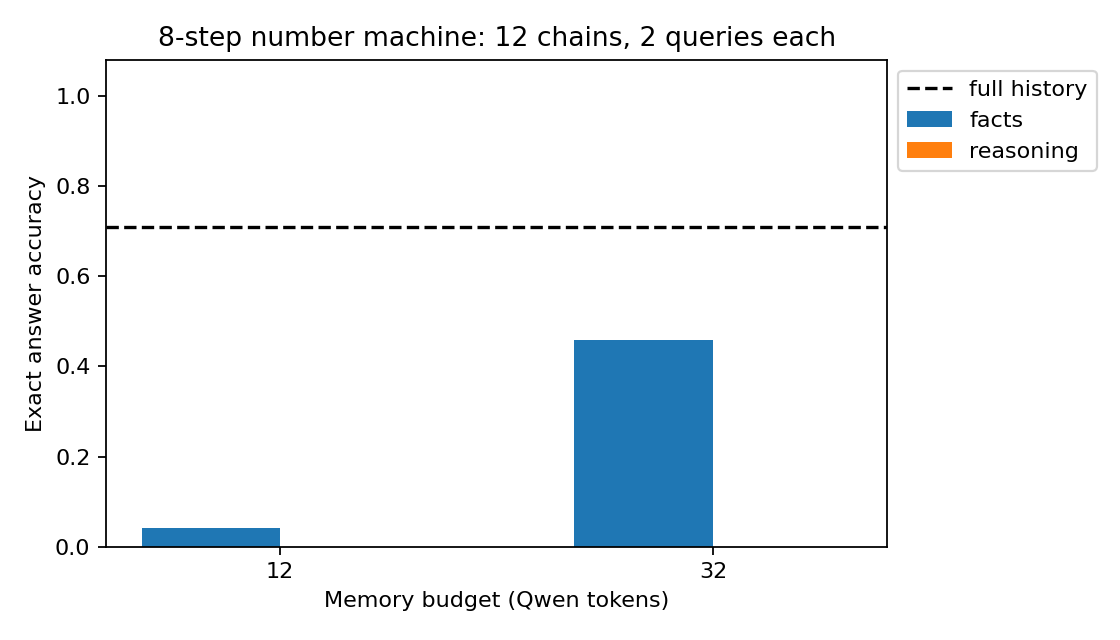

In [7]:
import matplotlib.pyplot as plt
import shutil
nm_fig, nm_ax = plt.subplots(figsize=(7,4))
for i, strategy in enumerate(('facts','reasoning')):
    values = [float(nm_summary[(nm_summary.strategy==strategy)&(nm_summary.budget==b)].accuracy.iloc[0])
              for b in NM_BUDGETS]
    nm_ax.bar(np.arange(len(NM_BUDGETS))+(i-.5)*.32, values, .32, label=strategy)
nm_ax.axhline(nm_full_accuracy, color='black', linestyle='--', label='full history')
nm_ax.set(xticks=np.arange(len(NM_BUDGETS)), xticklabels=[str(b) for b in NM_BUDGETS],
          xlabel='Memory budget (Qwen tokens)', ylabel='Exact answer accuracy', ylim=(0,1.08),
          title=f'8-step number machine: {NM_N_SEQUENCES} chains, 2 queries each')
nm_ax.legend(loc='upper left', bbox_to_anchor=(1,1))
nm_fig.tight_layout()
nm_fig.savefig(NM_RUN/'accuracy.png', dpi=160)
plt.show()
nm_archive = shutil.make_archive(str(NM_RUN), 'zip', NM_RUN)
print('Evidence archive:', nm_archive)


### 逐步状态保留率（不调用模型）

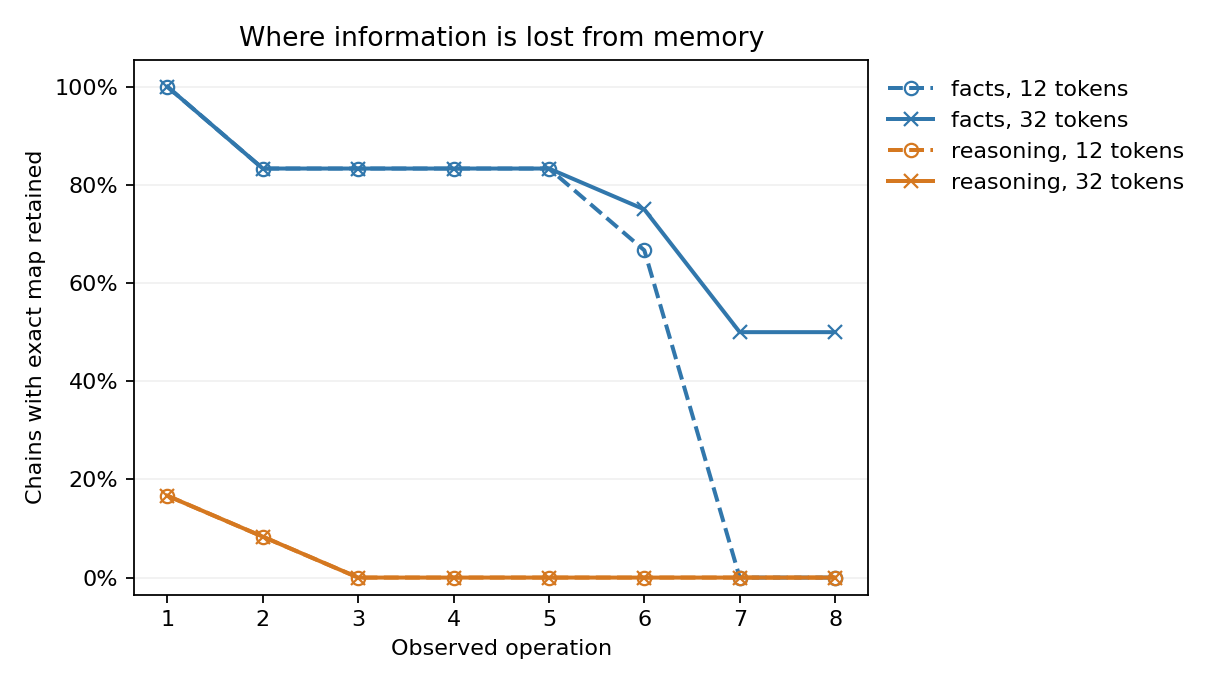

In [8]:
# Uses the completed run's logged states; makes no model calls.
from matplotlib.ticker import PercentFormatter
nm_step_summary = nm_traces.groupby(['strategy','budget','step']).agg(
    correct=('state_correct','sum'), chains=('state_correct','size'),
    accuracy=('state_correct','mean'), clipped=('truncated','sum')).reset_index()
nm_step_summary.to_csv(NM_RUN/'state_by_step.csv',index=False)
nm_state_fig, nm_state_ax = plt.subplots(figsize=(7.6,4.3))
for (strategy,budget),group in nm_step_summary.groupby(['strategy','budget']):
    nm_state_ax.plot(group.step,group.accuracy,label=f'{strategy}, {budget} tokens',
        color={'facts':'#3177ac','reasoning':'#d57820'}[strategy],
        linestyle='--' if budget==12 else '-', marker='o' if budget==12 else 'x',
        markerfacecolor='none',linewidth=1.8)
nm_state_ax.set(xlabel='Observed operation',ylabel='Chains with exact map retained',
    xticks=range(1,9),ylim=(-.035,1.055),title='Where information is lost from memory')
nm_state_ax.yaxis.set_major_formatter(PercentFormatter(1))
nm_state_ax.grid(axis='y',alpha=.18)
nm_state_ax.legend(loc='upper left',bbox_to_anchor=(1,1),frameon=False)
nm_state_fig.tight_layout()
nm_state_fig.savefig(NM_RUN/'state_by_step.png',dpi=160)
plt.show()


## 原始证据与复查

[查看本次证据 JSON](https://github.com/russellyaoduphd-cyber/520.637-HW-2/blob/091c209608d299b85f17291c2e616a2a54beb811/experiments/number_machine_v2/evidence.json) 在可读的汇总表之外，压缩保存了实际运行配置、数据、全部逻辑调用（含缓存来源）、逐步记忆和校准过程。下面的轻量代码可读取已保存结果，**不会调用模型**。

相关实现依据：[Qwen 官方模型卡](https://huggingface.co/Qwen/Qwen2.5-3B-Instruct)。本实验数据均来自此次运行，不来自模型卡的基准成绩。


In [ ]:
import json, gzip, base64, hashlib
from urllib.request import urlopen
import pandas as pd
with urlopen('https://raw.githubusercontent.com/russellyaoduphd-cyber/520.637-HW-2/091c209608d299b85f17291c2e616a2a54beb811/experiments/number_machine_v2/evidence.json') as response:
    nm_envelope = json.load(response)
nm_raw = gzip.decompress(base64.b64decode(nm_envelope['raw_evidence_gzip_base64']))
assert hashlib.sha256(nm_raw).hexdigest() == nm_envelope['raw_evidence_sha256']
nm_recorded = json.loads(nm_raw)
display(pd.DataFrame(nm_recorded['summary']))
display(pd.DataFrame(nm_recorded['state_summary']))
# For example: inspect one chain's raw memory transitions.
display(pd.DataFrame(nm_recorded['traces']).query("sequence == 'nm00'")[
    ['budget','strategy','step','observation','memory','expected_map','decoded_map','state_correct']])
